In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [7]:
df_cluster = pd.read_csv("NepalAgriStats_Cereal.csv")
df_cluster.isna().sum()
print(df_cluster.columns.to_list())


['DISTRICT_CODE', 'DISTRICT_NAME', 'PD_P_197980', 'PD_P_198081', 'PD_P_198182', 'PD_P_198283', 'PD_P_198384', 'PD_P_198485', 'PD_P_198586', 'PD_P_198687', 'PD_P_198788', 'PD_P_198889', 'PD_P_199091', 'PD_P_199192', 'PD_P_199293', 'PD_P_199394', 'PD_P_199495', 'PD_P_199596', 'PD_P_199697', 'PD_P_199798', 'PD_P_199899', 'PD_P_199900', 'PD_P_200001', 'PD_P_200102', 'PD_P_200203', 'PD_P_200304', 'PD_P_200405', 'PD_P_200506', 'PD_P_200607', 'PD_P_200708', 'PD_P_200809', 'PD_P_200910', 'PD_P_201011', 'PD_P_201112', 'PD_P_201213', 'PD_P_201314', 'MZ_P_197980', 'MZ_P_198081', 'MZ_P_198182', 'MZ_P_198283', 'MZ_P_198384', 'MZ_P_198485', 'MZ_P_198586', 'MZ_P_198687', 'MZ_P_198788', 'MZ_P_198889', 'MZ_P_199091', 'MZ_P_199192', 'MZ_P_199293', 'MZ_P_199394', 'MZ_P_199495', 'MZ_P_199596', 'MZ_P_199697', 'MZ_P_199798', 'MZ_P_199899', 'MZ_P_199900', 'MZ_P_200001', 'MZ_P_200102', 'MZ_P_200203', 'MZ_P_200304', 'MZ_P_200405', 'MZ_P_200506', 'MZ_P_200607', 'MZ_P_200708', 'MZ_P_200809', 'MZ_P_200910', 'MZ_P

In [23]:
paddy_cols = [col for col in df_cluster.columns if col.startswith('PD_P_')]
maize_cols = [col for col in df_cluster.columns if col.startswith('MZ_P_')]
millet_cols = [col for col in df_cluster.columns if col.startswith('ML_P_')]
wheat_cols = [col for col in df_cluster.columns if col.startswith('WT_P_')]

df_cluster['Paddy_mean'] = df_cluster[paddy_cols].mean(axis=1)
df_cluster['Maize_mean'] = df_cluster[maize_cols].mean(axis=1)
df_cluster['Millet_mean'] = df_cluster[millet_cols].mean(axis=1)
df_cluster['Wheat_mean'] = df_cluster[wheat_cols].mean(axis=1)

# Copy the engineered features
df = df_cluster[['Paddy_mean','Maize_mean','Millet_mean','Wheat_mean']].copy()

# FIX: Assign it back to permanently drop rows with missing values
df = df.dropna() 



In [24]:
scaler = StandardScaler()
X_data = df[['Paddy_mean',	'Maize_mean',	'Millet_mean',	'Wheat_mean']]
X_s = scaler.fit_transform(X_data)

for k in range(2,11):
    k_means = KMeans(n_clusters=k,random_state=42)
    k_means.fit(X_s)
    scou = silhouette_score(X_s,k_means.labels_)
    print(f"K : {k}  and  score: {scou}")
    

K : 2  and  score: 0.30454232267592296
K : 3  and  score: 0.45526272774847515
K : 4  and  score: 0.4475838270533942
K : 5  and  score: 0.435629642957402
K : 6  and  score: 0.4427195061048796
K : 7  and  score: 0.39720266434698115
K : 8  and  score: 0.4070848955984227
K : 9  and  score: 0.3934334490571001
K : 10  and  score: 0.3466365178775009


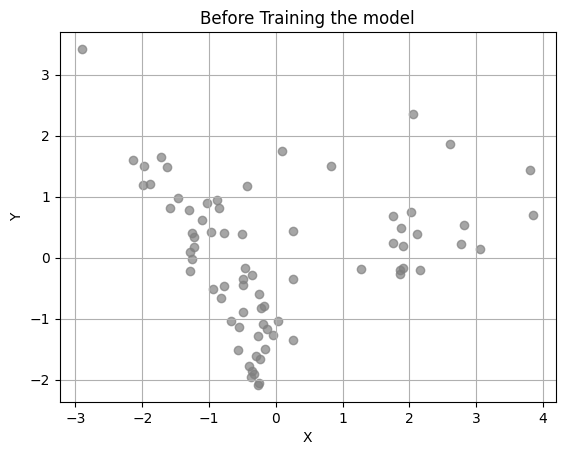

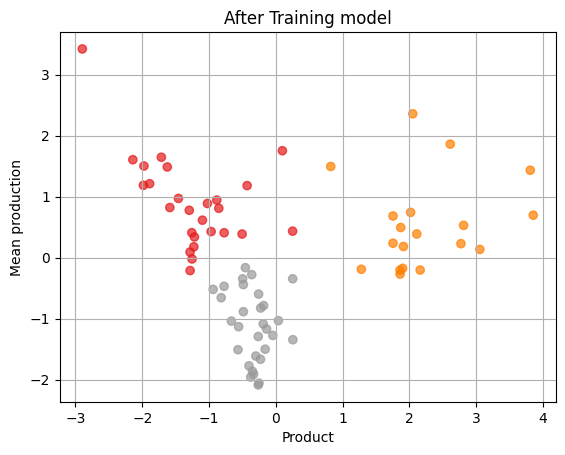

In [25]:
x_pca = PCA(n_components=2)
X_pca = x_pca.fit_transform(X_s)

# Before Prediction

plt.scatter(X_pca[:,0], X_pca[:,1], c="gray", alpha=0.7)
plt.title("Before Training the model")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

# Training the model

model = KMeans(n_clusters=3, random_state=42)
model.fit(X_pca)
labels = model.labels_

# Model After Training

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, alpha=0.7, cmap="Set1")
plt.title("After Training model")
plt.xlabel("Product")
plt.ylabel("Mean production")
plt.grid()
plt.show()


In [28]:

# 1. Attach the labels back to your cleaned dataframe
df['Cluster'] = labels

# 2. Group by cluster and calculate the average for each engineered feature
cluster_summary = df.groupby('Cluster')[['Paddy_mean', 'Maize_mean', 'Millet_mean', 'Wheat_mean']].mean()

print("=== CROP PRODUCTION PROFILES PER CLUSTER ===")
print(cluster_summary)



=== CROP PRODUCTION PROFILES PER CLUSTER ===
            Paddy_mean    Maize_mean  Millet_mean    Wheat_mean
Cluster                                                        
0         27277.453158  30800.740877  6717.574525   8650.550000
1        134198.557006  13864.771749   617.032508  34400.116362
2         10169.124871  10224.799642  1680.133627   6367.386090


In [30]:
# Add the district names back to the final sliced dataframe
# (Ensuring indices align if you dropped any rows during dropna)
df['District'] = df_cluster.loc[df.index, 'DISTRICT_NAME'] 

# Print out the districts in each cluster to verify your domain logic
for cluster_id in range(3):
    print(f"\n--- Districts in Cluster {cluster_id} ---")
    districts = df[df['Cluster'] == cluster_id]['District'].unique()
    print(", ".join(map(str, districts[:10]))) # Prints first 10 as a preview



--- Districts in Cluster 0 ---
Panchthar, Ilam, Sankhuwasabha, Bhojpur, Dhankuta, Okhaldhunga, Khotang, Ramechhap, Sindhuli, Sindhupalchok

--- Districts in Cluster 1 ---
Jhapa, Morang, Sunsari, Saptari, Siraha, Dhanusa, Mahottari, Sarlahi, Rautahat, Bara

--- Districts in Cluster 2 ---
Taplejung, Tehrathum, Solukhumbu, Udayapur, Dolakha, Bhaktapur, Lalitpur, Kathmandu, Rasuwa, Manang
